In [1]:
#Random Sampling

In [2]:
# Sample : A portion of overall population
# Population : the total dataset available
# N(N): POPULATION SIZE
# Random Sampling : Sample by Randomly pickimng portions of popuation
# Simple Random Sample : Samples the results without breaking them into Strta
# Stratus() : Groups that the data is split into.
# Bias : Systematic error
# Sample bias : A sample that misrepresnt the population
# Statified Sampling : Random samples that are taken after you split the total data into section or srata . Dividing the data in age group.

In [ ]:
# Selection Bias : Bias that results from how observation in data are selected
# Data Snooping : Searching through data in order to find something intresting with in it .
#  To prevent this it is very important that you look through all of your data through modelling.

#Vast Search effect : A form of selection bias where one repeatedly run different models asking differnent moodels asking different
# questions on a large data set which increases the chance that an outlier is deemed intresting . One way to combat this 
# is to have a holdout set of data that one can test their conclusion on.

# Target Shuffling : Another menthod to combat the vast search effect where one creates a model  and notes its efficacy ,
# then shuffle the target variable around so your data is wrong 

In [ ]:
#Regression to Mean : Refer to the phenomenon  that  extreme observation trend to be followed by one closer to mean .

In [ ]:
# Sampling Distribution of a Statistics : When working with large amount of data sampling becomes very important and sice a sample is not a perfect representation of the population ,
# it is important to understand sampling variability.

In [ ]:
# The Central Limit Theorem (CLT) states that if you take sufficiently large random samples
# from a population with any shape of distribution, the distribution of the sample means will approximate a normal distribution, 
# no matter the shape of the original population distribution.

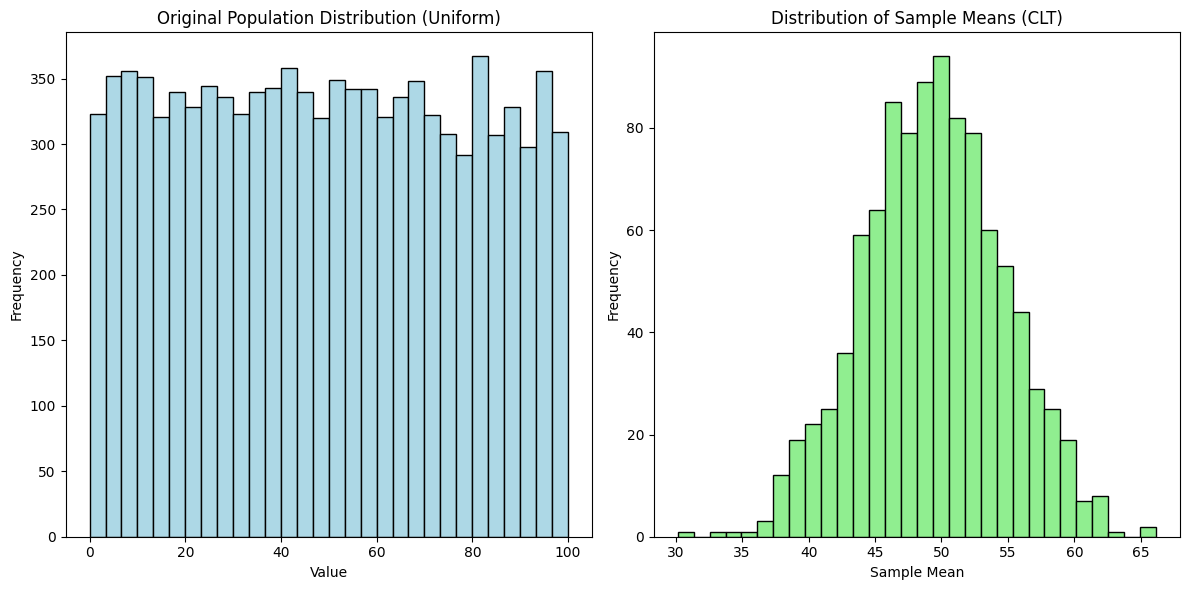

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
np.random.seed(42)

# Step 1: Generate a non-normal distribution (Uniform Distribution)
population_data = np.random.uniform(low=0, high=100, size=10000)

# Step 2: Parameters for sampling
sample_size = 30  # Number of items in each sample
n_samples = 1000  # Number of samples

# Step 3: Collect sample means
sample_means = []
for _ in range(n_samples):
    sample = np.random.choice(population_data, size=sample_size, replace=False)
    sample_means.append(np.mean(sample))

# Step 4: Plot the original population distribution
plt.figure(figsize=(12, 6))

# Plot original population distribution
plt.subplot(1, 2, 1)
plt.hist(population_data, bins=30, color='lightblue', edgecolor='black')
plt.title('Original Population Distribution (Uniform)')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot the distribution of sample means (Central Limit Theorem in action)
plt.subplot(1, 2, 2)
plt.hist(sample_means, bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Sample Means (CLT)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')

# Show both plots
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

In [8]:
df_player =pd.read_excel("../Data/Athletes.xlsx")

In [9]:
df_player

,Name,NOC,Discipline
0,AALERUD Katrine,Norway,Cycling Road
1,ABAD Nestor,Spain,Artistic Gymnastics
2,ABAGNALE Giovanni,Italy,Rowing
3,ABALDE Alberto,Spain,Basketball
4,ABALDE Tamara,Spain,Basketball
...,...,...,...
11080,ZWICKER Martin Detlef,Germany,Hockey
11081,ZWOLINSKA Klaudia,Poland,Canoe Slalom
11082,ZYKOVA Yulia,ROC,Shooting
11083,ZYUZINA Ekaterina,ROC,Sailing


In [17]:
df_player["Name"].apply(
    lambda x: x.split(" ")[0] + "--" + x.split(" ")[1] if len(x.split(" ")) == 2 else x
)

0             AALERUD--Katrine
1                 ABAD--Nestor
2           ABAGNALE--Giovanni
3              ABALDE--Alberto
4               ABALDE--Tamara
                 ...          
11080    ZWICKER Martin Detlef
11081       ZWOLINSKA--Klaudia
11082            ZYKOVA--Yulia
11083       ZYUZINA--Ekaterina
11084         ZYZANSKA--Sylwia
Name: Name, Length: 11085, dtype: object

In [ ]:
#Standard Error
# df_player["x"].sem()

In [ ]:
#The Bootstrap

#this is a sampling method where we draw resamples from a sample replace the values in the resample back to the sample then draw thgem again.


Original DataFrame:
       Value
0  54.967142
1  48.617357
2  56.476885
3  65.230299
4  47.658466

Original Sample Mean: 48.96153482605907

Bootstrap Standard Error: 0.8811254321948779

Bootstrap Bias: 0.01530118909273881


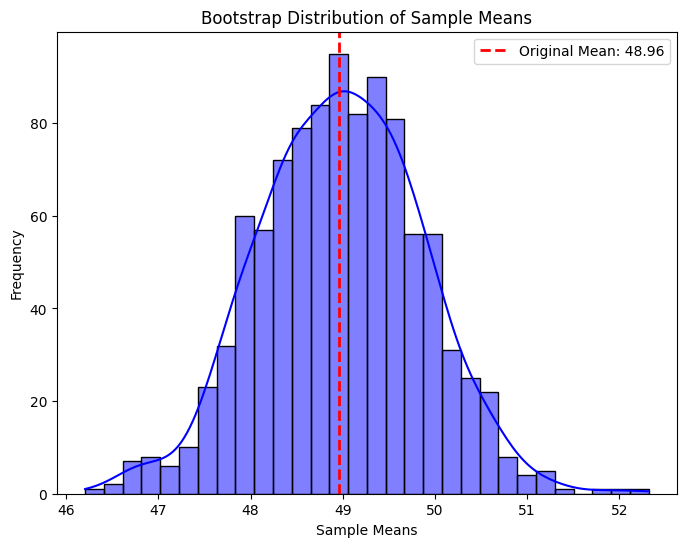

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create a sample DataFrame
np.random.seed(42)

# Let's assume we have some data representing a population
data = {
    'Value': np.random.normal(loc=50, scale=10, size=100)  # Normal distribution (mean=50, std=10)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Show the first few rows of the data
print("Original DataFrame:")
print(df.head())

# Step 2: Calculate the original sample mean
original_mean = df['Value'].mean()
print(f"\nOriginal Sample Mean: {original_mean}")

# Step 3: Perform bootstrapping
n_iterations = 1000  # Number of bootstrap iterations
bootstrap_means = []

for _ in range(n_iterations):
    # Resample with replacement from the data
    bootstrap_sample = df['Value'].sample(n=len(df), replace=True)
    # Calculate the mean of the bootstrap sample
    bootstrap_means.append(bootstrap_sample.mean())

# Step 4: Calculate the Standard Error (SE)
bootstrap_means = np.array(bootstrap_means)
standard_error = bootstrap_means.std()
print(f"\nBootstrap Standard Error: {standard_error}")

# Step 5: Calculate the Bias (Difference between mean of bootstrap samples and the original mean)
bias = bootstrap_means.mean() - original_mean
print(f"\nBootstrap Bias: {bias}")

# Step 6: Plot the distribution of the bootstrap sample means
plt.figure(figsize=(8, 6))
sns.histplot(bootstrap_means, kde=True, color='blue', bins=30)
plt.axvline(original_mean, color='red', linestyle='dashed', linewidth=2, label=f'Original Mean: {original_mean:.2f}')
plt.title("Bootstrap Distribution of Sample Means")
plt.xlabel("Sample Means")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:
#Confidence interval :

# the percentage of confidence interval constructed in the same way 
# from the same population that we are expected to contain the statistics of interest.

In [19]:
import numpy as np
import scipy.stats as stats

# Step 1: Create a sample dataset
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=10, size=100)  # Mean=50, Std=10, Sample size=100

# Step 2: Calculate sample mean and standard deviation
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)  # Sample standard deviation (using ddof=1 for unbiased estimator)
sample_size = len(sample_data)

# Step 3: Calculate the standard error (SE)
standard_error = sample_std / np.sqrt(sample_size)

# Step 4: Calculate the critical t value for a 95% confidence level
# Degrees of freedom = sample_size - 1
confidence_level = 0.95
alpha = 1 - confidence_level
df = sample_size - 1  # degrees of freedom
t_critical = stats.t.ppf(1 - alpha / 2, df)  # t critical value for two-tailed test

# Step 5: Calculate the margin of error
margin_of_error = t_critical * standard_error

# Step 6: Calculate the confidence interval
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

# Output results
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Standard Error: {standard_error:.2f}")
print(f"T Critical Value: {t_critical:.2f}")
print(f"Margin of Error: {margin_of_error:.2f}")
print(f"{confidence_level*100}% Confidence Interval: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")


Sample Mean: 48.96
Standard Error: 0.91
T Critical Value: 1.98
Margin of Error: 1.80
95.0% Confidence Interval: (47.16, 50.76)


In [22]:
import numpy as np
import scipy.stats as stats

# Step 1: Create a sample dataset
np.random.seed(33)
sample_data = np.random.normal(loc=50, scale=10, size=100)  # Mean=50, Std=10, Sample size=100

# Step 2: Define the confidence level
confidence_level = 0.95  # 95% confidence interval

# Step 3: Calculate the sample mean and the standard error
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)  # Use ddof=1 for sample standard deviation
sample_size = len(sample_data)

# Step 4: Calculate the confidence interval using scipy.stats.t.interval
# The t.interval function gives the confidence interval for the mean based on the sample data
ci_lower, ci_upper = stats.t.interval(confidence_level, df=sample_size-1, loc=sample_mean, scale=sample_std/np.sqrt(sample_size))

# Output the results
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"{confidence_level*100}% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")


Sample Mean: 49.62
Sample Standard Deviation: 10.36
95.0% Confidence Interval: (47.56, 51.68)


In [23]:
#normal/Guassian Distribution

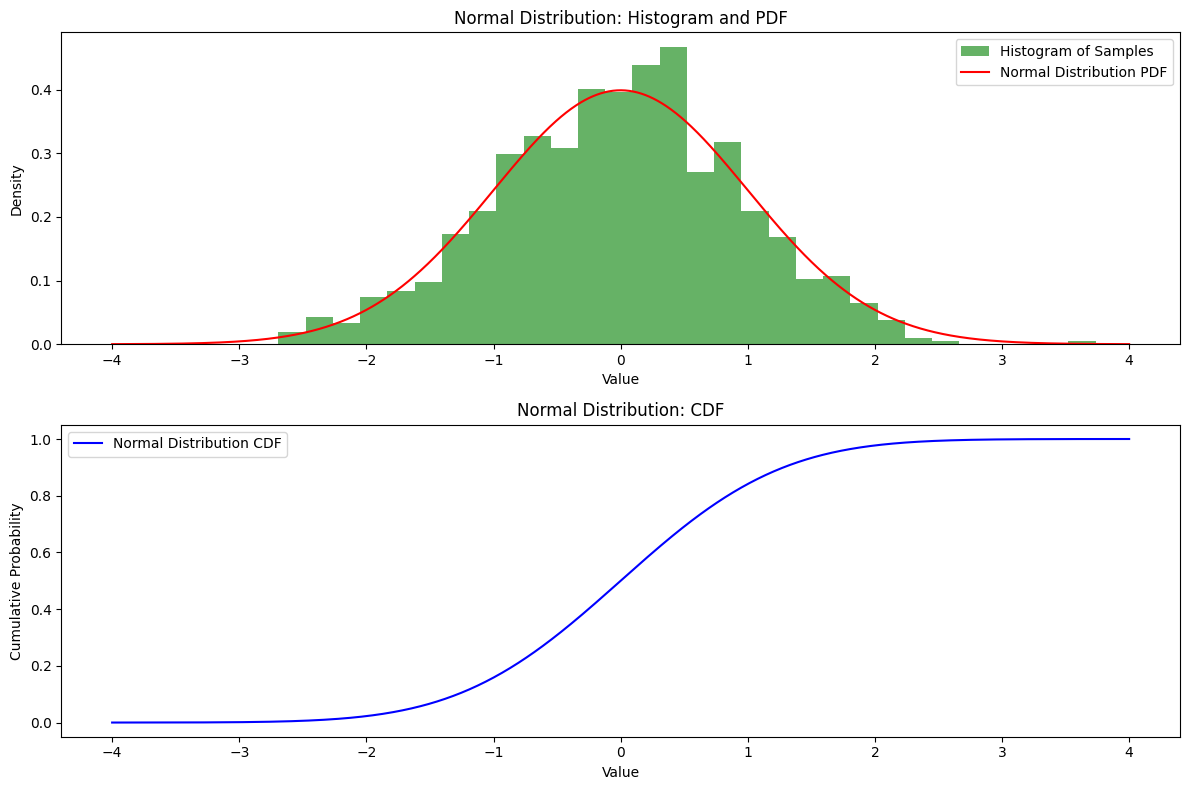

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Parameters for the normal distribution
mu = 0        # Mean
sigma = 1     # Standard deviation
size = 1000   # Number of samples

# Step 1: Generate random samples from the normal distribution
samples = np.random.normal(loc=mu, scale=sigma, size=size)

# Step 2: Calculate the PDF (Probability Density Function) of the normal distribution
x_values = np.linspace(-4, 4, 1000)  # Generate 1000 points between -4 and 4
pdf_values = stats.norm.pdf(x_values, loc=mu, scale=sigma)  # PDF of normal distribution

# Step 3: Calculate the CDF (Cumulative Distribution Function) of the normal distribution
cdf_values = stats.norm.cdf(x_values, loc=mu, scale=sigma)  # CDF of normal distribution

# Step 4: Plotting the results

plt.figure(figsize=(12, 8))

# Plot the histogram of the samples
plt.subplot(2, 1, 1)
plt.hist(samples, bins=30, density=True, alpha=0.6, color='g', label='Histogram of Samples')
plt.plot(x_values, pdf_values, 'r-', label='Normal Distribution PDF')
plt.title('Normal Distribution: Histogram and PDF')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

# Plot the CDF
plt.subplot(2, 1, 2)
plt.plot(x_values, cdf_values, 'b-', label='Normal Distribution CDF')
plt.title('Normal Distribution: CDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.legend()

plt.tight_layout()
plt.show()


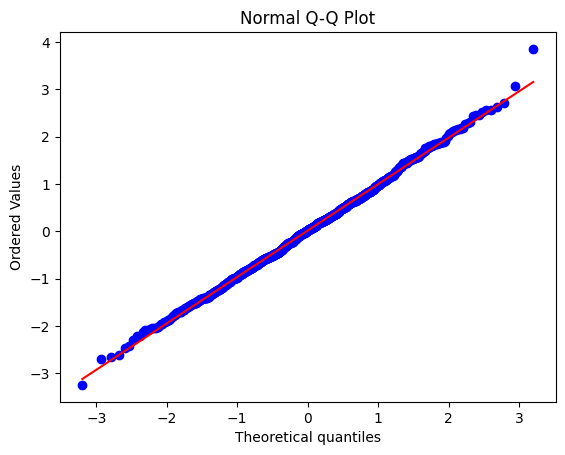

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Step 1: Create a sample dataset from a normal distribution
np.random.seed(42)
sample_data = np.random.normal(loc=0, scale=1, size=1000)  # Mean=0, Std=1, Sample size=1000

# Step 2: Generate a probability plot to check if the data follows a normal distribution
stats.probplot(sample_data, dist="norm", plot=plt)

# Step 3: Display the plot
plt.title("Normal Q-Q Plot")
plt.show()


In [ ]:
#long tail distribution

# A long-tail distribution refers to a distribution where a large proportion of the values
# in the dataset are clustered around a small number of observations, but there is a small 
# number of observations with very large values (or outliers) that stretch the tail of the distribution 
# to the right (positive skew) or left (negative skew). This type of distribution is characterized
# by a "heavy tail" where a small number of extreme values can significantly affect the distribution.

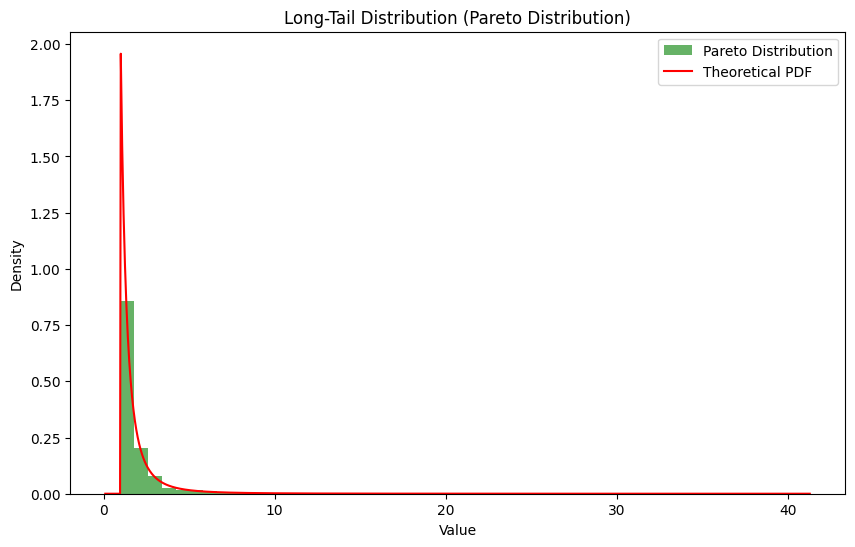

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Parameters for the Pareto distribution (shape parameter)
alpha = 2.0  # Shape parameter (controls the "heaviness" of the tail)
size = 1000   # Number of samples

# Step 1: Generate random data from the Pareto distribution
long_tail_data = stats.pareto.rvs(alpha, size=size)

# Step 2: Plot the data
plt.figure(figsize=(10, 6))
plt.hist(long_tail_data, bins=50, density=True, alpha=0.6, color='g', label='Pareto Distribution')
plt.title('Long-Tail Distribution (Pareto Distribution)')
plt.xlabel('Value')
plt.ylabel('Density')

# Plot the theoretical PDF of the Pareto distribution
x_values = np.linspace(0.1, np.max(long_tail_data), 1000)
pdf_values = stats.pareto.pdf(x_values, alpha)
plt.plot(x_values, pdf_values, 'r-', label='Theoretical PDF')

plt.legend()
plt.show()


In [ ]:
# The Student's t-distribution is a probability distribution that is symmetric and bell-shaped, 
# like the normal distribution, but with heavier tails. This means it accounts for the possibility
# of more extreme values (outliers). It is commonly used in hypothesis testing, 
# particularly for small sample sizes, when the population standard deviation is unknown.

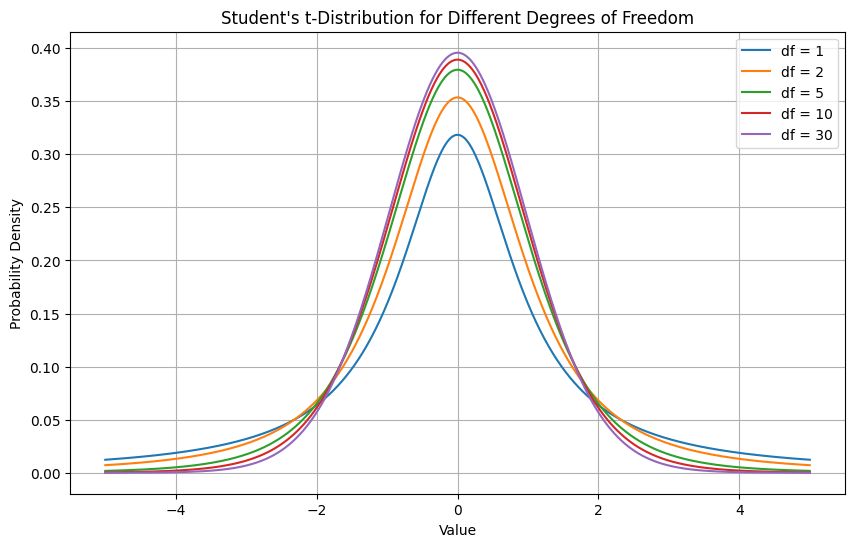

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Parameters for the t-distribution
df_values = [1, 2, 5, 10, 30]  # Different degrees of freedom for comparison
x = np.linspace(-5, 5, 1000)  # Range of x-values

# Plotting the t-distribution for different degrees of freedom
plt.figure(figsize=(10, 6))

for df in df_values:
    pdf_values = stats.t.pdf(x, df)  # Compute the PDF for the t-distribution
    plt.plot(x, pdf_values, label=f'df = {df}')  # Plot each distribution

plt.title("Student's t-Distribution for Different Degrees of Freedom")
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# The Binomial Distribution is a discrete probability 
# distribution that describes the number of successes in a fixed number of 
# independent trials of a binary (yes/no) experiment. Each trial has the same probability of success,
# and we are interested in the total number of successes in those trials.



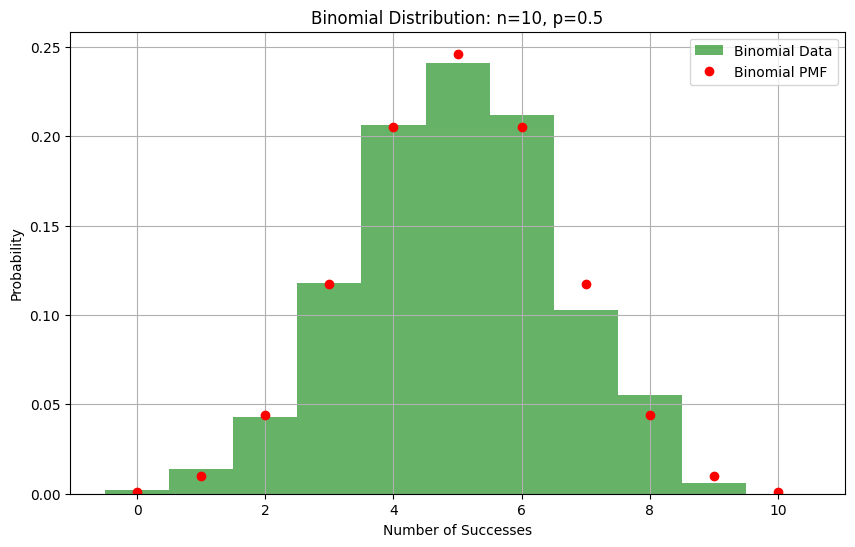

Probability of exactly 5 successes: 0.2461
Cumulative probability of 5 or fewer successes: 0.6230


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Parameters for the Binomial distribution
n = 10  # Number of trials
p = 0.5  # Probability of success
size = 1000  # Number of samples to generate

# Step 1: Generate random data from a Binomial distribution
binomial_data = np.random.binomial(n, p, size)

# Step 2: Plot the histogram of the binomial data
plt.figure(figsize=(10, 6))
plt.hist(binomial_data, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.6, color='g', label='Binomial Data')

# Step 3: Plot the Binomial probability mass function (PMF)
x = np.arange(0, n+1)
pmf_values = stats.binom.pmf(x, n, p)
plt.plot(x, pmf_values, 'ro', label='Binomial PMF')

# Step 4: Adding titles and labels
plt.title(f'Binomial Distribution: n={n}, p={p}')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Calculate the probability of getting exactly 5 successes
prob_5_successes = stats.binom.pmf(5, n, p)
print(f"Probability of exactly 5 successes: {prob_5_successes:.4f}")

# Step 6: Calculate the cumulative probability of getting 5 or fewer successes
cum_prob_5_or_fewer = stats.binom.cdf(5, n, p)
print(f"Cumulative probability of 5 or fewer successes: {cum_prob_5_or_fewer:.4f}")


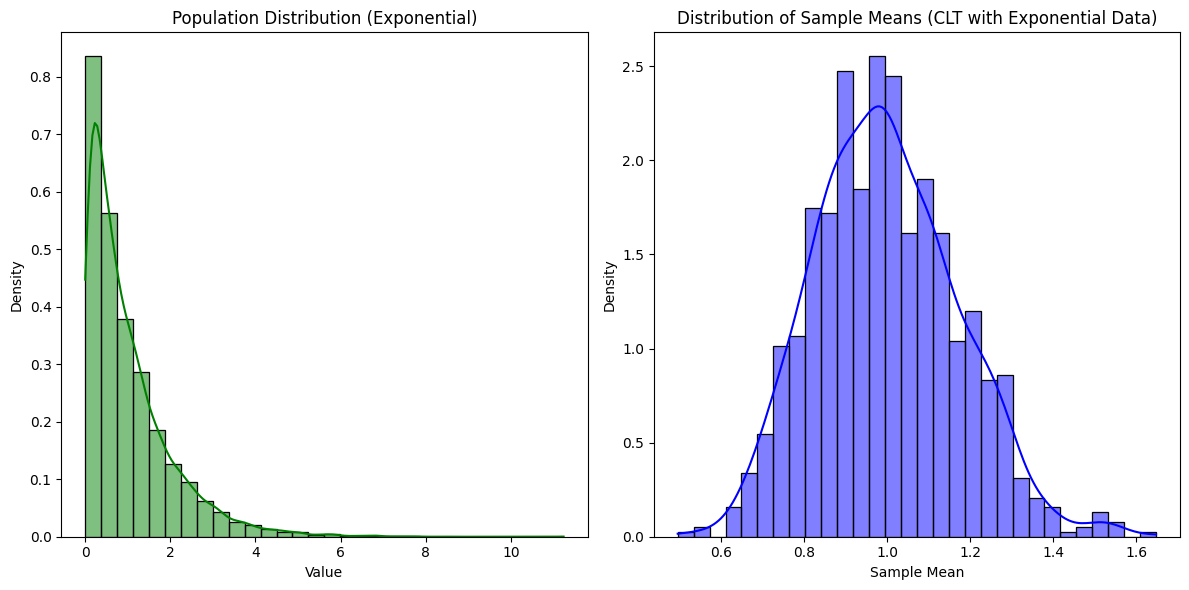

In [30]:
# Step 1: Generate data from an exponential distribution
population_data_exp = np.random.exponential(scale=1, size=population_size)

# Step 2: Generate sample means from the exponential population
sample_means_exp = []

for _ in range(n_samples):
    sample = np.random.choice(population_data_exp, size=sample_size, replace=False)
    sample_means_exp.append(np.mean(sample))

# Step 3: Plot the exponential population and the sample means
plt.figure(figsize=(12, 6))

# Plot the original population distribution (exponential distribution)
plt.subplot(1, 2, 1)
sns.histplot(population_data_exp, bins=30, kde=True, color='green', stat="density", label='Population (Exponential)')
plt.title("Population Distribution (Exponential)")
plt.xlabel('Value')
plt.ylabel('Density')

# Plot the distribution of sample means
plt.subplot(1, 2, 2)
sns.histplot(sample_means_exp, bins=30, kde=True, color='blue', stat="density", label='Sample Means')
plt.title("Distribution of Sample Means (CLT with Exponential Data)")
plt.xlabel('Sample Mean')
plt.ylabel('Density')

# Show the plot
plt.tight_layout()
plt.show()


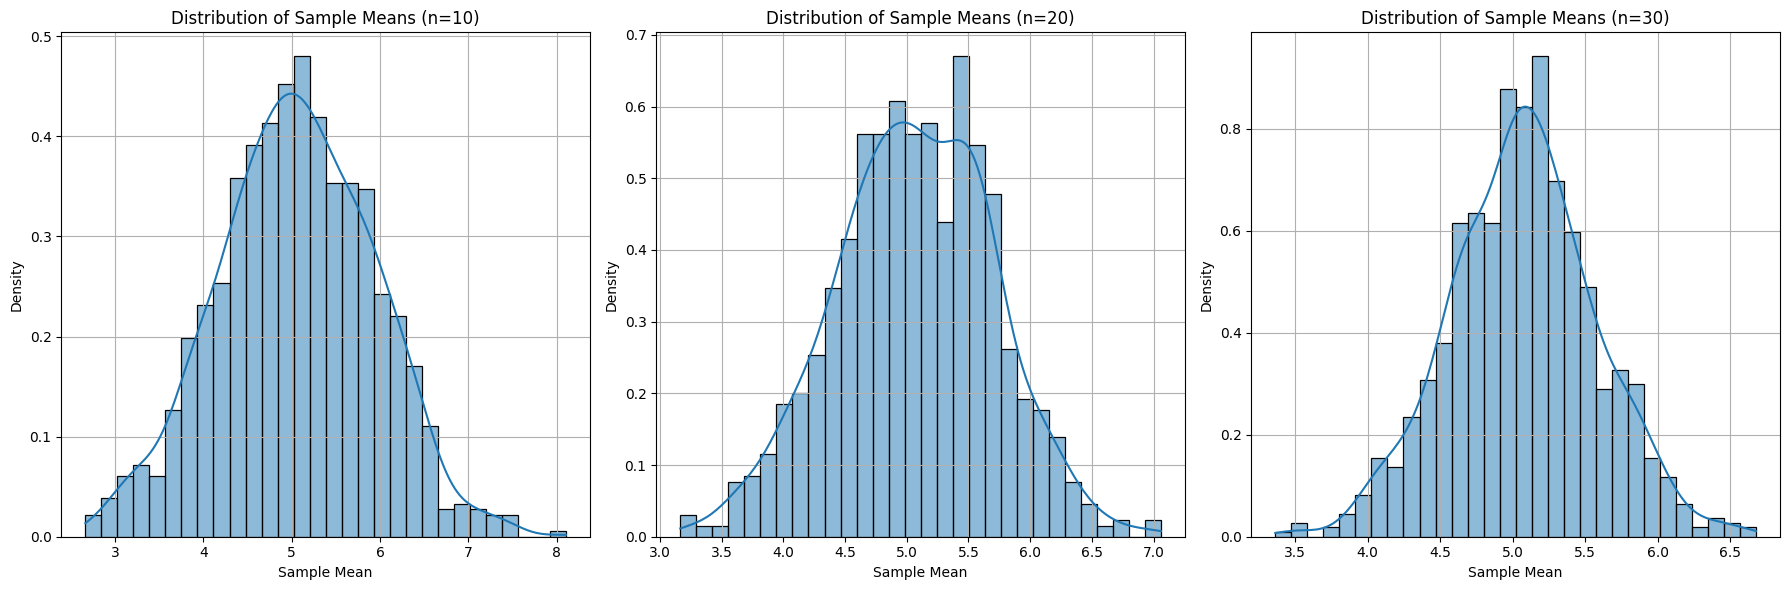

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters for simulation
population_size = 10000  # Population size
n_samples = 1000         # Number of samples to draw

# Generate data from a non-normal distribution (uniform distribution)
population_data = np.random.uniform(low=0, high=10, size=population_size)

# Sample sizes to test
sample_sizes = [10, 20, 30]

# Create a figure to plot the results
plt.figure(figsize=(18, 6))

# Loop over different sample sizes
for i, sample_size in enumerate(sample_sizes, start=1):
    # Step 2: Generate sample means for the current sample size
    sample_means = []
    
    for _ in range(n_samples):
        sample = np.random.choice(population_data, size=sample_size, replace=False)
        sample_means.append(np.mean(sample))
    
    # Plot the sample means distribution for the current sample size
    plt.subplot(1, 3, i)
    sns.histplot(sample_means, bins=30, kde=True, stat="density", label=f'Sample Size = {sample_size}')
    plt.title(f"Distribution of Sample Means (n={sample_size})")
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()


In [ ]:
# The Chi-Square Distribution is a special case of the Gamma distribution 
# and is commonly used in statistical inference, particularly in hypothesis testing and 
# constructing confidence intervals for population variances. It is a continuous probability 
# distribution that
# arises in the context of variances, especially when dealing with sample variance in normally distributed data.

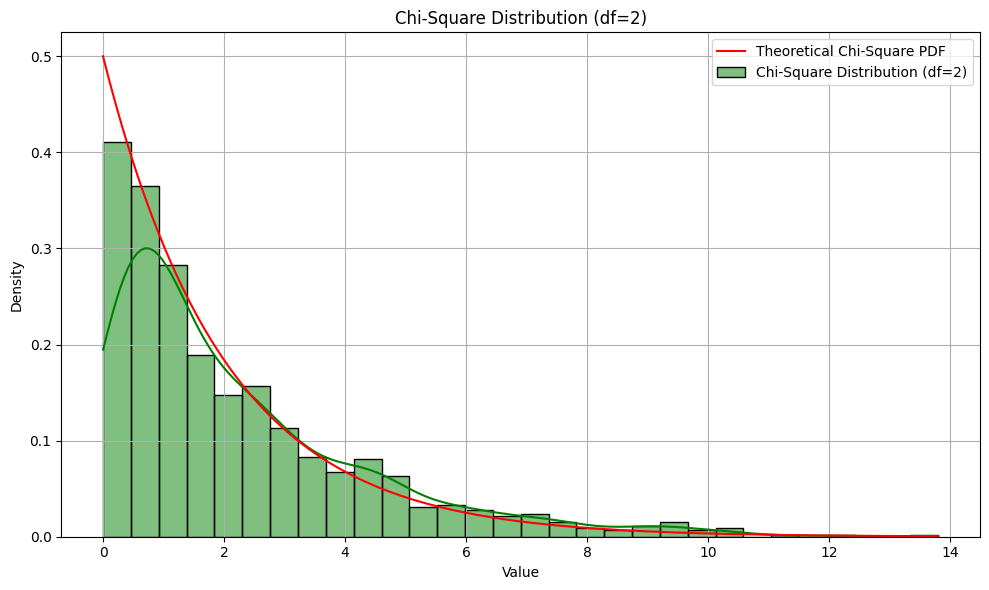

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set the degrees of freedom (df)
degrees_of_freedom = 2  # You can change this to 1, 5, 10, etc.

# Generate random data from a Chi-Square distribution
sample_size = 1000
chi_square_data = np.random.chisquare(df=degrees_of_freedom, size=sample_size)

# Plot the distribution of Chi-Square data
plt.figure(figsize=(10, 6))
sns.histplot(chi_square_data, bins=30, kde=True, color='green', stat="density", label=f'Chi-Square Distribution (df={degrees_of_freedom})')

# Plot the theoretical Chi-Square distribution
x = np.linspace(0, np.max(chi_square_data), 1000)
pdf_values = stats.chi2.pdf(x, df=degrees_of_freedom)
plt.plot(x, pdf_values, 'r-', label=f'Theoretical Chi-Square PDF')

# Add labels and legend
plt.title(f'Chi-Square Distribution (df={degrees_of_freedom})')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
# The Poisson Distribution is a discrete probability distribution used to model
# the number of events occurring in a fixed interval of time or space, given that these 
# events happen independently and at a constant average rate. It is commonly 
# used in scenarios where you are counting the number of events that occur randomly but with a known average frequency

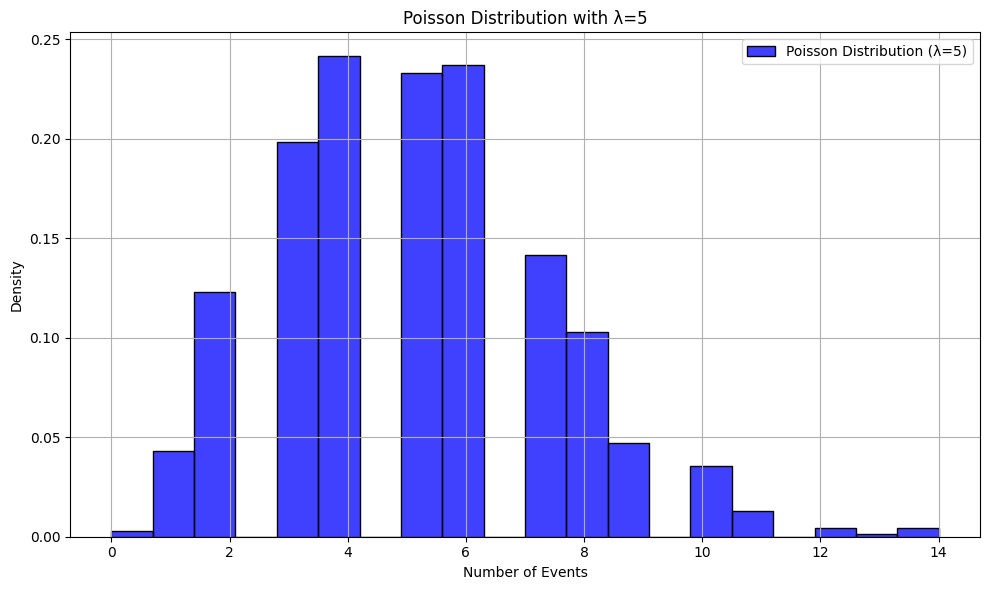

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the rate parameter (λ)
lambda_param = 5  # Average number of events (mean)

# Generate random data from a Poisson distribution
sample_size = 1000
poisson_data = np.random.poisson(lam=lambda_param, size=sample_size)

# Plot the distribution of Poisson data
plt.figure(figsize=(10, 6))

sns.histplot(poisson_data, bins=20, kde=False, color='blue', stat="density", label=f'Poisson Distribution (λ={lambda_param})')

# Add title and labels
plt.title(f'Poisson Distribution with λ={lambda_param}')
plt.xlabel('Number of Events')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
# Exponential Distribution
# The Exponential Distribution is a continuous 
# probability distribution often used to model the time between events in a Poisson process. 
# It is commonly used to represent the time until an event occurs, such as the time until a phone call 
# arrives at a call center, the time until a radioactive particle decays, or the time between arrivals in a queue.



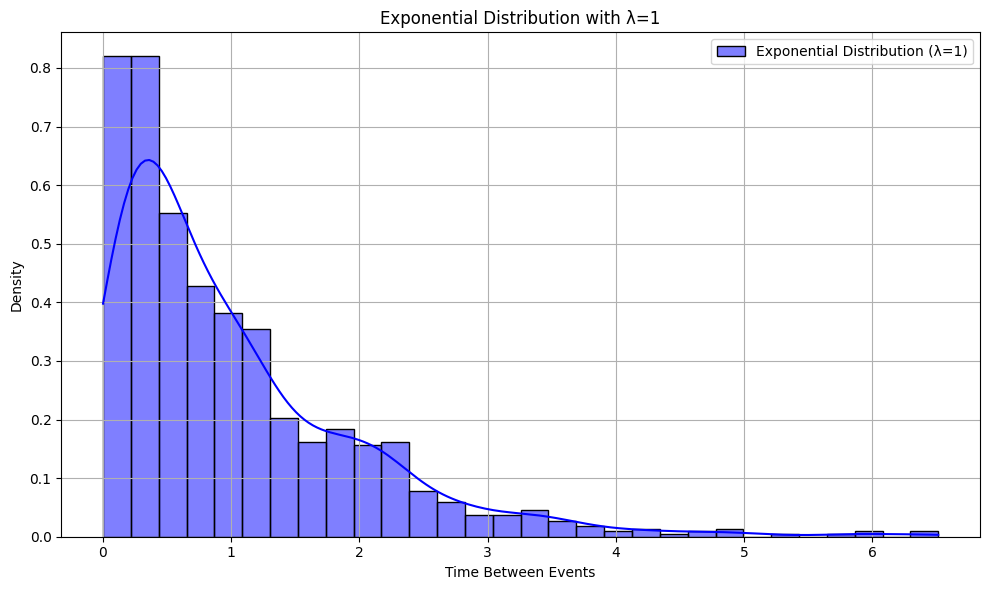

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the rate parameter (λ)
lambda_param = 1  # Rate parameter (mean is 1/λ)

# Generate random data from an Exponential distribution
sample_size = 1000
exponential_data = np.random.exponential(scale=1/lambda_param, size=sample_size)

# Plot the distribution of Exponential data
plt.figure(figsize=(10, 6))

sns.histplot(exponential_data, bins=30, kde=True, color='blue', stat="density", label=f'Exponential Distribution (λ={lambda_param})')

# Add title and labels
plt.title(f'Exponential Distribution with λ={lambda_param}')
plt.xlabel('Time Between Events')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [36]:
# Weibull Distribution
# The Weibull Distribution is a continuous probability distribution named after the
# Swedish mathematician Wallodi Weibull. It is widely used in reliability analysis, survival studies,
# and modeling the time until a certain event occurs, particularly in engineering and life data analysis.
#poisson & distribution

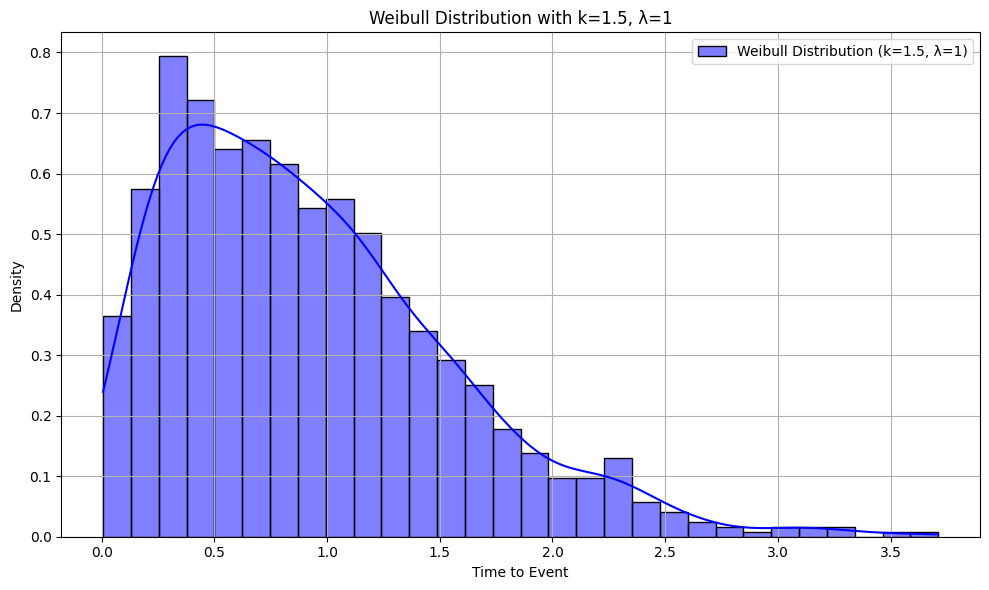

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the parameters for the Weibull distribution
k = 1.5  # Shape parameter (also known as the Weibull index)
lambda_param = 1  # Scale parameter

# Generate random data from a Weibull distribution
sample_size = 1000
weibull_data = np.random.weibull(a=k, size=sample_size) * lambda_param

# Plot the distribution of Weibull data
plt.figure(figsize=(10, 6))

sns.histplot(weibull_data, bins=30, kde=True, color='blue', stat="density", label=f'Weibull Distribution (k={k}, λ={lambda_param})')

# Add title and labels
plt.title(f'Weibull Distribution with k={k}, λ={lambda_param}')
plt.xlabel('Time to Event')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()
